---
# PART A: CNN from Scratch (Keras / TensorFlow)

## 1. Setup & Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

!pip install tensorflow --quiet
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!unzip -q "/content/drive/MyDrive/Insect Classification-20260430T073507Z-3-001.zip" -d /content/

replace /content/Insect Classification/test/aphids/jpg_56.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace /content/Insect Classification/test/aphids/jpg_56.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


## 2. Data Understanding, Analysis, Visualization & Cleaning

In [4]:
base_path  = "/content/Insect Classification"
train_path = os.path.join(base_path, "train")
test_path  = os.path.join(base_path, "test")

classes = sorted(os.listdir(train_path))
print("Classes:", classes)
print("Number of classes:", len(classes))

train_counts = {c: len(os.listdir(os.path.join(train_path, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(test_path,  c))) for c in classes}

print("\nTrain counts:", train_counts)
print("Test counts: ", test_counts)
print("Total train:", sum(train_counts.values()))
print("Total test: ", sum(test_counts.values()))

Classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']
Number of classes: 9

Train counts: {'aphids': 266, 'armyworm': 223, 'beetle': 291, 'bollworm': 245, 'grasshopper': 277, 'mites': 254, 'mosquito': 295, 'sawfly': 200, 'stem_borer': 181}
Test counts:  {'aphids': 44, 'armyworm': 43, 'beetle': 50, 'bollworm': 36, 'grasshopper': 46, 'mites': 42, 'mosquito': 50, 'sawfly': 37, 'stem_borer': 36}
Total train: 2232
Total test:  384


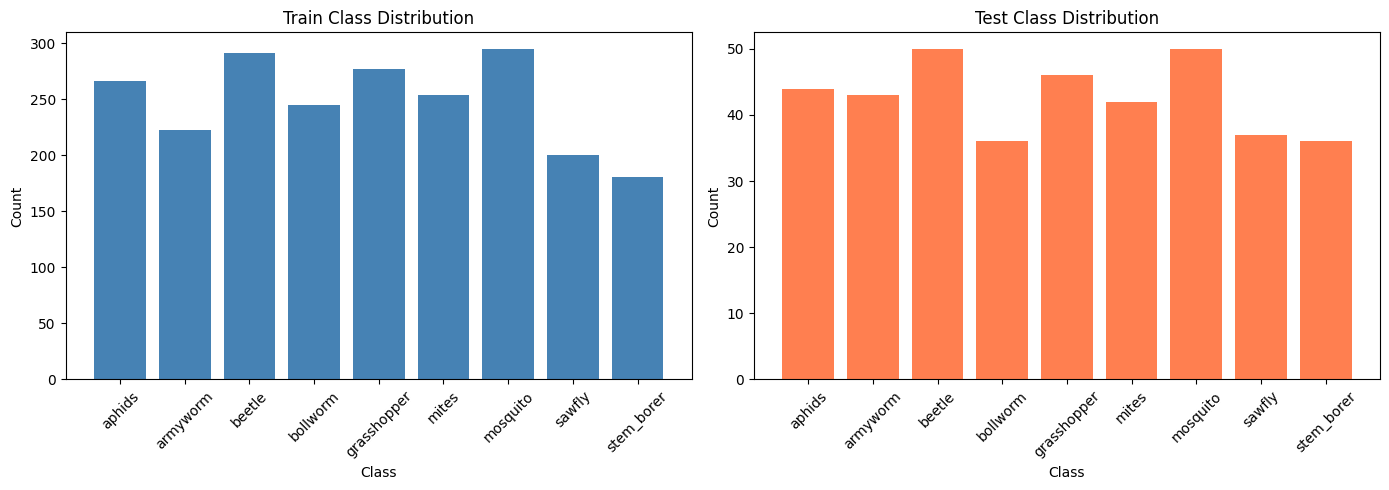

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue')
axes[0].set_title("Train Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(test_counts.keys(), test_counts.values(), color='coral')
axes[1].set_title("Test Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

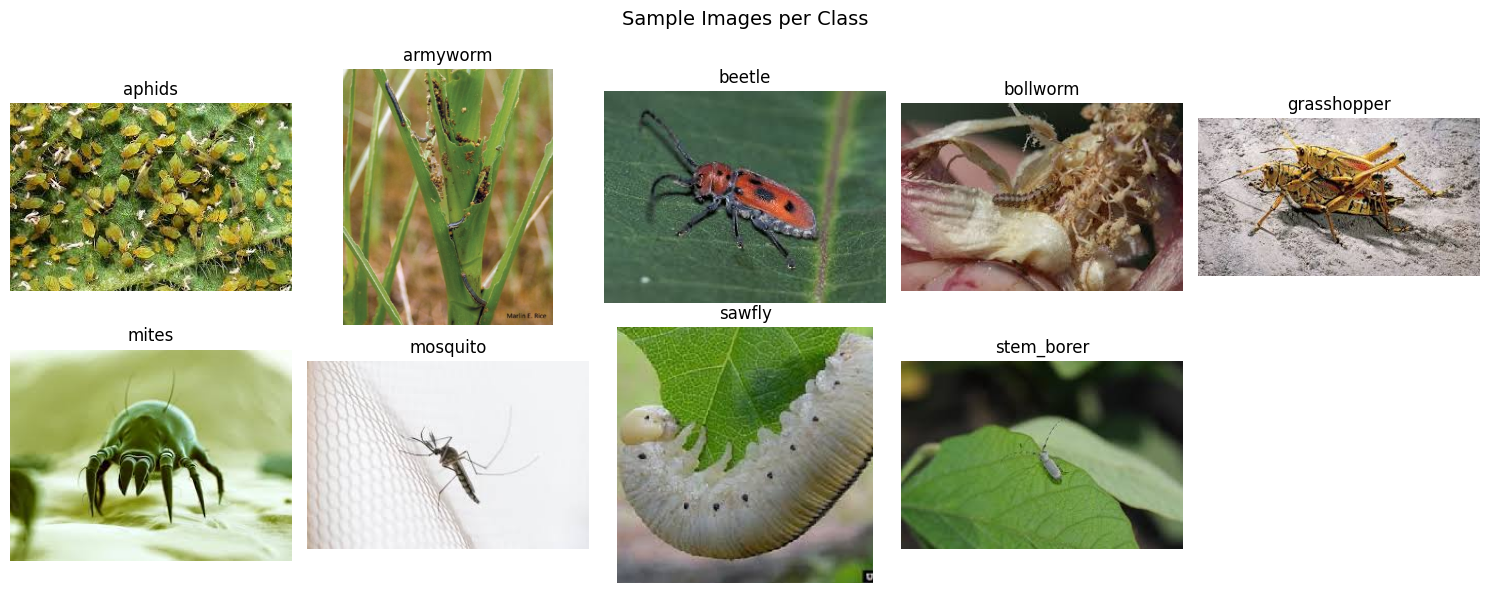

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
    img = Image.open(os.path.join(train_path, cls, img_name)).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle("Sample Images per Class", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
removed = 0
for split in ['train', 'test']:
    split_path = os.path.join(base_path, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
            except:
                os.remove(img_path)
                removed += 1
print(f"Removed {removed} corrupted images.")

Removed 121 corrupted images.


## 3. Preprocessing & Data Augmentation

**Preprocessing choices:**
- Resize all images to 128x128 (standard ImageNet input size, improves feature richness)
- Normalize pixel values to [0, 1] via `rescale=1./255`
- 20% of training data held out as validation split

**Augmentation applied to training only:**
- Horizontal flip — insects can appear mirrored
- Rotation ±20° — images taken from varied angles
- Zoom 20% — simulate distance variation
- Width/height shift 10% — positional variance


In [9]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
SEED       = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
NUM_CLASSES = len(class_names)
print("Classes:", class_names)


Found 1692 images belonging to 9 classes.
Found 419 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
Classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


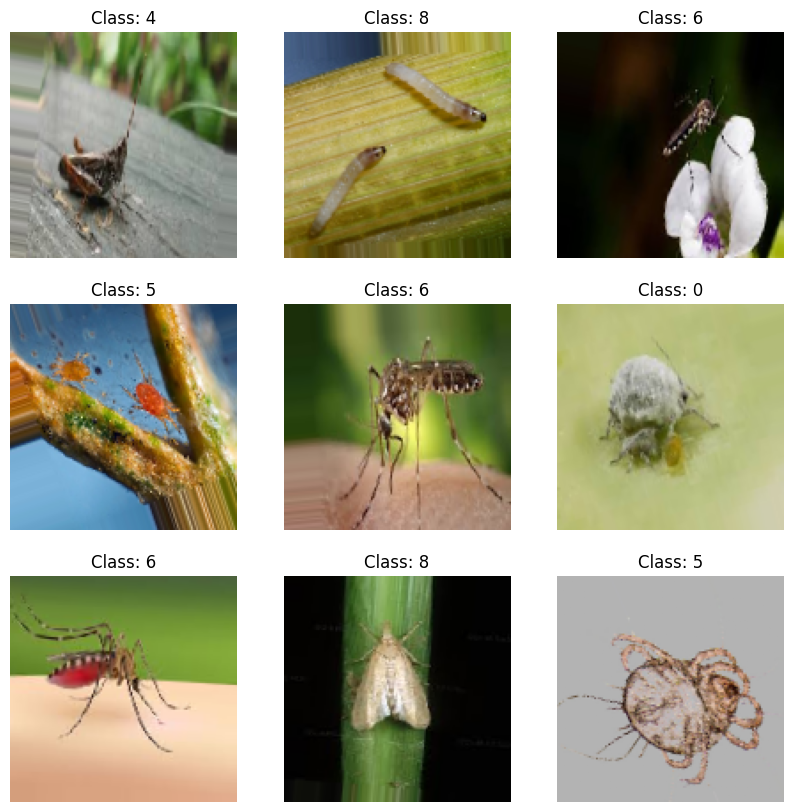

In [10]:
# --- INSERT AFTER DATA GENERATOR DEFINITION ---
import matplotlib.pyplot as plt

def visualize_augmentations(generator):
    # Fetch a single batch
    batch = next(generator)
    images = batch[0]
    labels = batch[1]

    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(f"Class: {np.argmax(labels[i])}")
        plt.axis('off')
    plt.show()

visualize_augmentations(train_gen)

## 4. Baseline CNN Model

**Architecture:** 3 Conv blocks (Conv → ReLU → MaxPool) + 3 Dense layers + Softmax output  
**Rationale:** Shallow architecture to establish a performance floor before adding complexity.

In [11]:
def build_baseline(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        # Conv Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Conv Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        # Fully Connected Layers
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_baseline(NUM_CLASSES)
baseline_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,849 (32.52 MB)

 Trainable params: 8,523,849 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

t0 = time.time()
baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)
baseline_train_time = time.time() - t0
print(f"\nBaseline training time: {baseline_train_time:.1f}s")

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 361ms/step - accuracy: 0.1826 - loss: 2.1483 - val_accuracy: 0.2076 - val_loss: 2.0732
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 240ms/step - accuracy: 0.2931 - loss: 1.9384 - val_accuracy: 0.2768 - val_loss: 1.9684
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 267ms/step - accuracy: 0.3517 - loss: 1.7293 - val_accuracy: 0.3198 - val_loss: 1.8812
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 275ms/step - accuracy: 0.4427 - loss: 1.5590 - val_accuracy: 0.3055 - val_loss: 1.8564
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 276ms/step - accuracy: 0.4982 - loss: 1.3809 - val_accuracy: 0.3938 - val_loss: 1.8409
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.5561 - loss: 1.2479 - val_accuracy: 0.3413 - val_loss: 1.9758
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 268ms/step - accuracy: 0.6158 - loss: 1.1100 - val_accuracy: 0.3437 - val_loss: 1.8852
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 266ms/step - accuracy: 0.6803 - loss: 0.9427 - val_accu

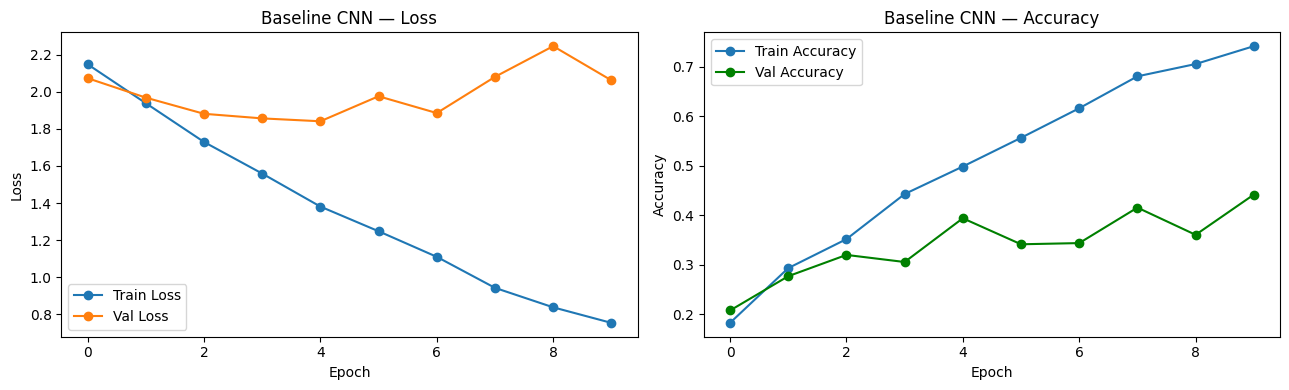

In [13]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss',     marker='o')
    axes[0].plot(history.history['val_loss'], label='Val Loss',       marker='o')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', marker='o')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   marker='o', color='green')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, 'Baseline CNN')

Baseline Test Accuracy: 0.5026  |  Test Loss: 1.5092
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step

Classification Report:
              precision    recall  f1-score   support

      aphids       0.57      0.64      0.60        44
    armyworm       0.59      0.23      0.33        43
      beetle       0.39      0.90      0.55        50
    bollworm       0.55      0.58      0.57        36
 grasshopper       0.36      0.22      0.27        46
       mites       0.56      0.43      0.49        42
    mosquito       0.66      0.82      0.73        50
      sawfly       0.32      0.27      0.29        37
  stem_borer       0.83      0.28      0.42        36

    accuracy                           0.50       384
   macro avg       0.54      0.49      0.47       384
weighted avg       0.53      0.50      0.48       384



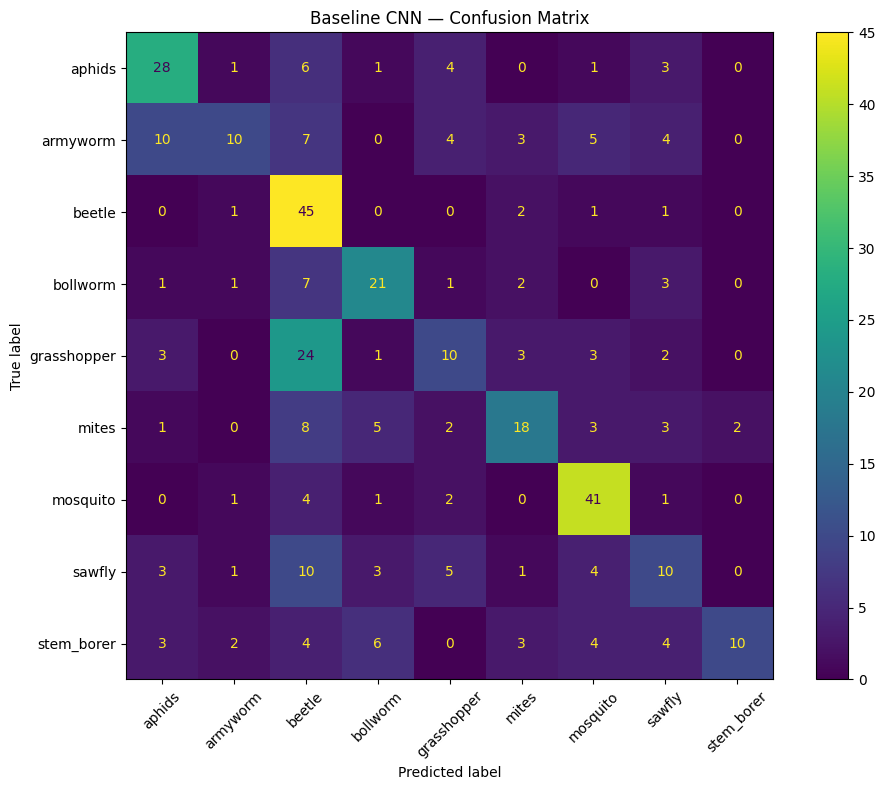

In [14]:
test_gen.reset()
baseline_loss, baseline_acc = baseline_model.evaluate(test_gen, verbose=0)
print(f"Baseline Test Accuracy: {baseline_acc:.4f}  |  Test Loss: {baseline_loss:.4f}")

test_gen.reset()
baseline_preds = np.argmax(baseline_model.predict(test_gen), axis=1)
baseline_labels = test_gen.classes

print("\nClassification Report:")
print(classification_report(baseline_labels, baseline_preds, target_names=class_names))

cm = confusion_matrix(baseline_labels, baseline_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Baseline CNN — Confusion Matrix")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step


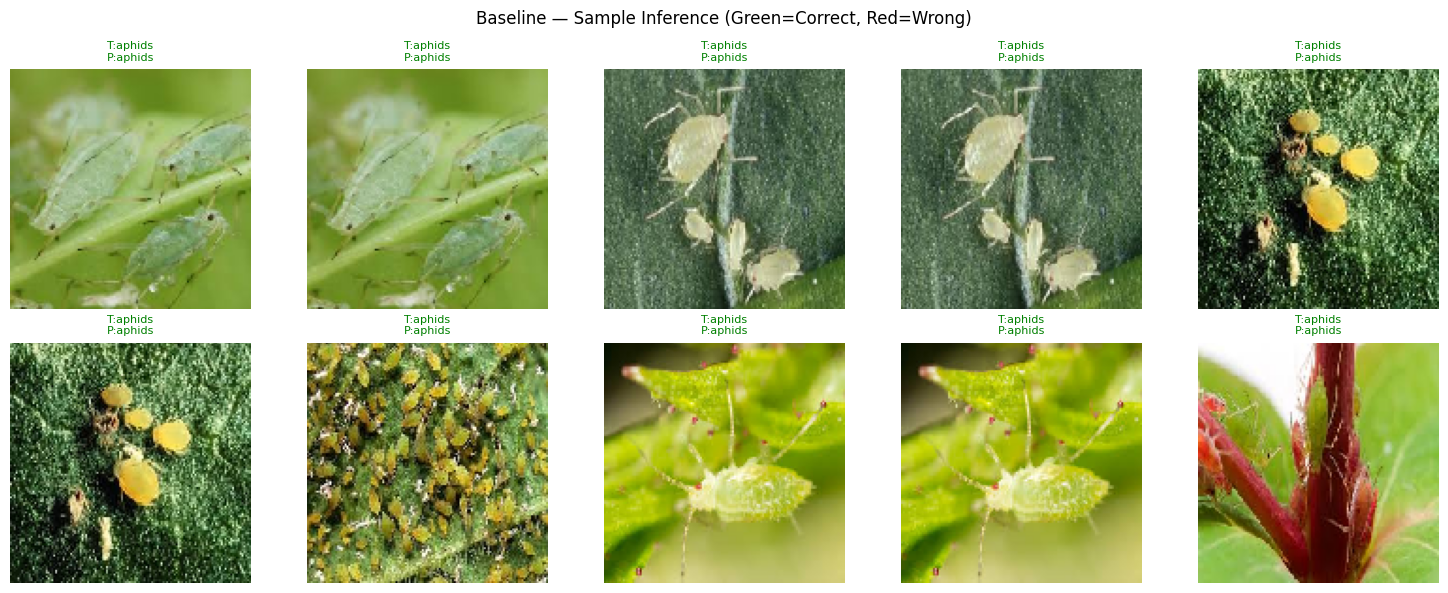

In [15]:
test_gen.reset()
sample_x, sample_y = next(test_gen)
sample_preds = np.argmax(baseline_model.predict(sample_x[:10]), axis=1)
sample_true  = np.argmax(sample_y[:10], axis=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_x[i])
    color = 'green' if sample_preds[i] == sample_true[i] else 'red'
    ax.set_title(f"T:{class_names[sample_true[i]]}\nP:{class_names[sample_preds[i]]}",
                 color=color, fontsize=8)
    ax.axis('off')
plt.suptitle("Baseline — Sample Inference (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Deeper CNN with Regularization

**Changes from baseline:**
- **6 Conv blocks** (doubled from 3) with increasing filters: 32→64→128→256→256→512
- **Batch Normalization** after each Conv layer — stabilizes and accelerates training
- **Dropout** (0.4 after Conv blocks, 0.5 after Dense) — reduces overfitting
- **Global Average Pooling** instead of Flatten — reduces parameters, improves generalization

In [16]:
def build_deeper(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.4),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.4),

        layers.GlobalAveragePooling2D(),

        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model

deeper_model = build_deeper(NUM_CLASSES)
deeper_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,476,137 (5.63 MB)

 Trainable params: 1,472,681 (5.62 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [17]:
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

t0 = time.time()
deeper_history_adam = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=[early_stop],
    verbose=1
)
deeper_train_time_adam = time.time() - t0
print(f"\nDeeper CNN (Adam) training time: {deeper_train_time_adam:.1f}s")

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 62s 716ms/step - accuracy: 0.1436 - loss: 2.8816 - val_accuracy: 0.1623 - val_loss: 2.3182
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 259ms/step - accuracy: 0.1673 - loss: 2.6142 - val_accuracy: 0.1384 - val_loss: 2.4254
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - accuracy: 0.1927 - loss: 2.4144 - val_accuracy: 0.0931 - val_loss: 2.7971
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 255ms/step - accuracy: 0.2051 - loss: 2.3243 - val_accuracy: 0.1551 - val_loss: 2.4849
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - accuracy: 0.2524 - loss: 2.2098 - val_accuracy: 0.1623 - val_loss: 2.4179
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 252ms/step - accuracy: 0.2600 - loss: 2.1530 - val_accuracy: 0.1838 - val_loss: 2.5221
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 256ms/step - accuracy: 0.2742 - loss: 2.0912 - val_accuracy: 0.1671 - val_loss: 2.5701
Epoch 8/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.3008 - loss: 2.0009 - val_accu

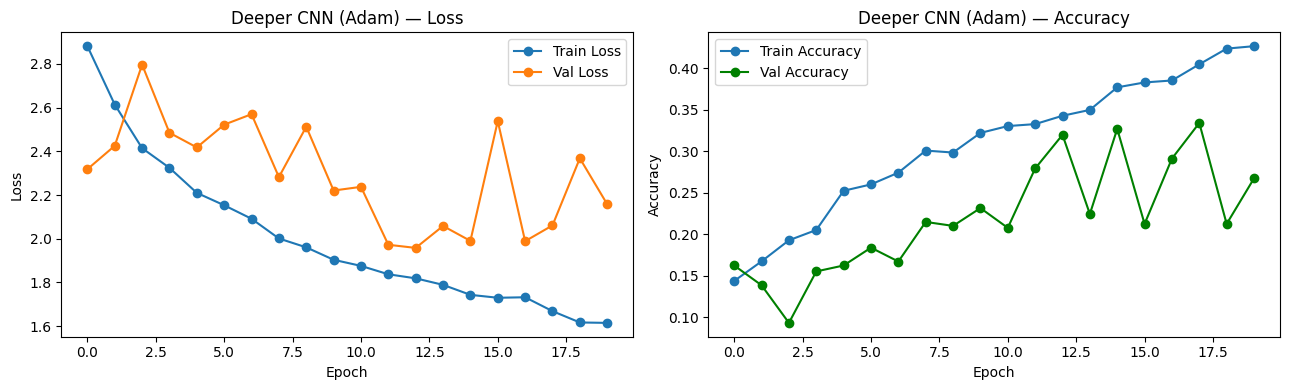

Deeper CNN (Adam) Test Accuracy: 0.3828  |  Loss: 1.7986
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step

Classification Report (Deeper — Adam):
              precision    recall  f1-score   support

      aphids       0.35      0.80      0.49        44
    armyworm       0.38      0.23      0.29        43
      beetle       0.45      0.74      0.56        50
    bollworm       0.21      0.25      0.23        36
 grasshopper       0.40      0.09      0.14        46
       mites       0.40      0.33      0.36        42
    mosquito       0.45      0.72      0.55        50
      sawfly       0.22      0.05      0.09        37
  stem_borer       0.00      0.00      0.00        36

    accuracy                           0.38       384
   macro avg       0.32      0.36      0.30       384
weighted avg       0.33      0.38      0.32       384



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


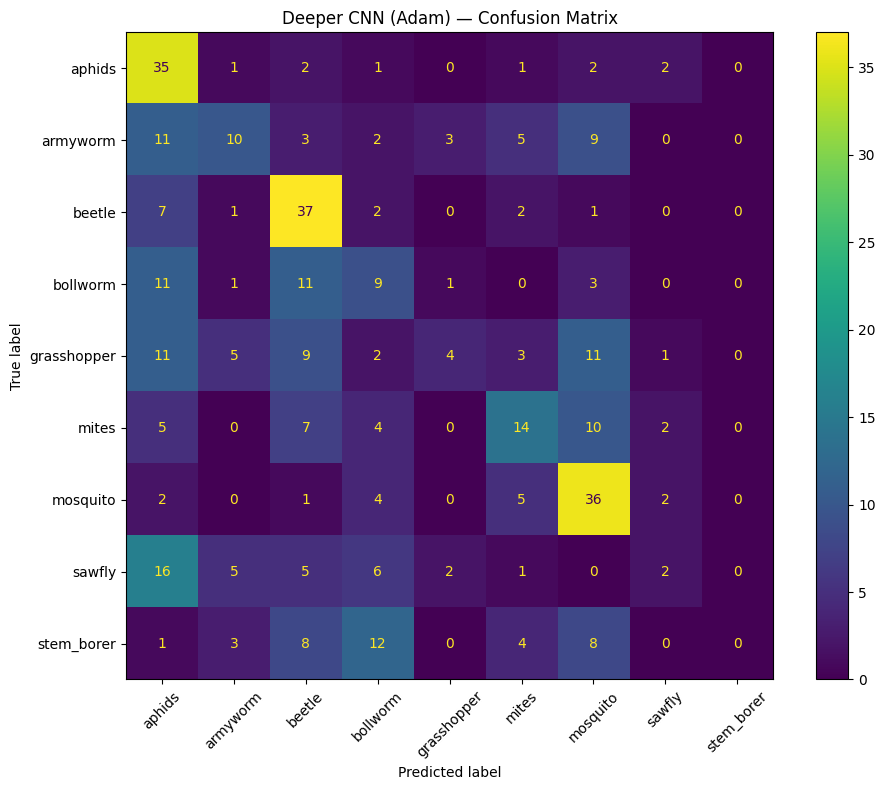

In [18]:
plot_history(deeper_history_adam, 'Deeper CNN (Adam)')

test_gen.reset()
deeper_loss_adam, deeper_acc_adam = deeper_model.evaluate(test_gen, verbose=0)
print(f"Deeper CNN (Adam) Test Accuracy: {deeper_acc_adam:.4f}  |  Loss: {deeper_loss_adam:.4f}")

test_gen.reset()
deeper_preds_adam = np.argmax(deeper_model.predict(test_gen), axis=1)
print("\nClassification Report (Deeper — Adam):")
print(classification_report(test_gen.classes, deeper_preds_adam, target_names=class_names))

cm = confusion_matrix(test_gen.classes, deeper_preds_adam)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Deeper CNN (Adam) — Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. Experimentation & Comparative Analysis
### 6.1 Optimizer Analysis: SGD vs Adam

In [19]:
deeper_model_sgd = build_deeper(NUM_CLASSES)
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

t0 = time.time()
deeper_history_sgd = deeper_model_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=[early_stop],
    verbose=1
)
deeper_train_time_sgd = time.time() - t0
print(f"\nDeeper CNN (SGD) training time: {deeper_train_time_sgd:.1f}s")

test_gen.reset()
_, deeper_acc_sgd = deeper_model_sgd.evaluate(test_gen, verbose=0)
print(f"Deeper CNN (SGD) Test Accuracy: {deeper_acc_sgd:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 481ms/step - accuracy: 0.1584 - loss: 2.8205 - val_accuracy: 0.1193 - val_loss: 61.8792
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - accuracy: 0.1791 - loss: 2.3534 - val_accuracy: 0.1002 - val_loss: 5.7592
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - accuracy: 0.2199 - loss: 2.1620 - val_accuracy: 0.2053 - val_loss: 2.5927
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - accuracy: 0.2618 - loss: 2.0781 - val_accuracy: 0.2482 - val_loss: 2.1383
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - accuracy: 0.2547 - loss: 2.0510 - val_accuracy: 0.2554 - val_loss: 2.1703
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step - accuracy: 0.2843 - loss: 1.9742 - val_accuracy: 0.2554 - val_loss: 2.0728
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 251ms/step - accuracy: 0.2801 - loss: 1.9585 - val_accuracy: 0.2721 - val_loss: 2.1017
Epoch 8/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 256ms/step - accuracy: 0.3014 - loss: 1.9002 - val_acc

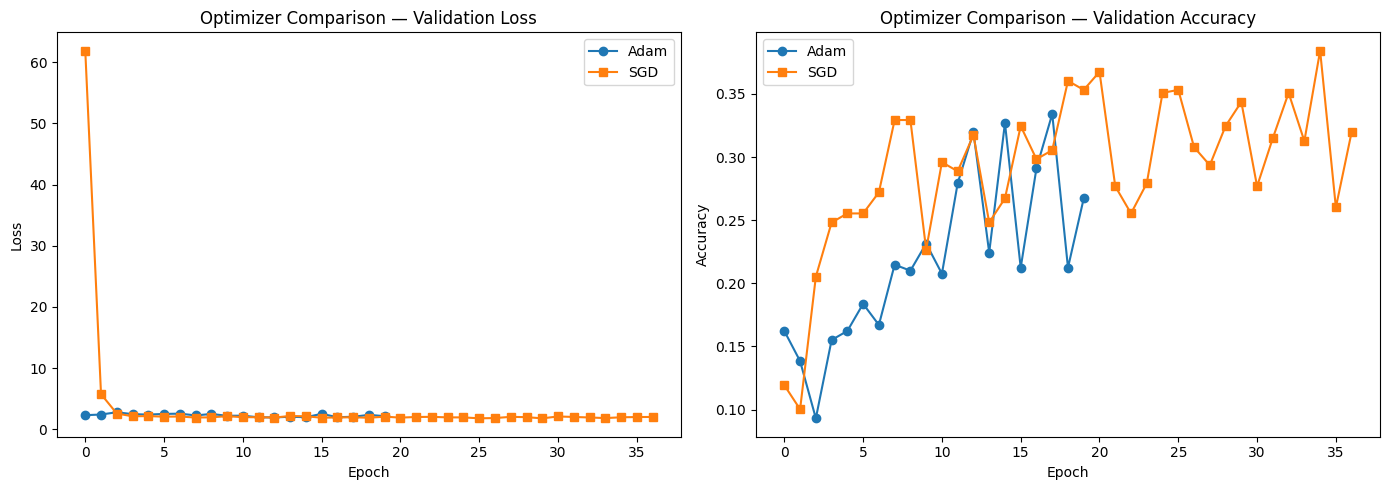

Adam final val accuracy: 0.2673
SGD  final val accuracy: 0.3198


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history_adam.history['val_loss'], label='Adam', marker='o')
axes[0].plot(deeper_history_sgd.history['val_loss'],  label='SGD',  marker='s')
axes[0].set_title('Optimizer Comparison — Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(deeper_history_adam.history['val_accuracy'], label='Adam', marker='o')
axes[1].plot(deeper_history_sgd.history['val_accuracy'],  label='SGD',  marker='s')
axes[1].set_title('Optimizer Comparison — Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Adam final val accuracy: {deeper_history_adam.history['val_accuracy'][-1]:.4f}")
print(f"SGD  final val accuracy: {deeper_history_sgd.history['val_accuracy'][-1]:.4f}")

### 6.2 Ablation Study — Remove Dropout

In [21]:
def build_deeper_no_dropout(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

ablation_model = build_deeper_no_dropout(NUM_CLASSES)
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

ablation_history = ablation_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=[early_stop],
    verbose=1
)

test_gen.reset()
_, ablation_acc = ablation_model.evaluate(test_gen, verbose=0)
print(f"\nAblation (No Dropout) Test Accuracy: {ablation_acc:.4f}")


Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 387ms/step - accuracy: 0.2914 - loss: 2.0244 - val_accuracy: 0.1885 - val_loss: 2.3483
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 255ms/step - accuracy: 0.4161 - loss: 1.6325 - val_accuracy: 0.1074 - val_loss: 2.6139
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 251ms/step - accuracy: 0.4864 - loss: 1.4478 - val_accuracy: 0.1050 - val_loss: 5.3161
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 251ms/step - accuracy: 0.5674 - loss: 1.2464 - val_accuracy: 0.1146 - val_loss: 7.6319
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step - accuracy: 0.5703 - loss: 1.2181 - val_accuracy: 0.1217 - val_loss: 6.5726
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step - accuracy: 0.6288 - loss: 1.0532 - val_accuracy: 0.1337 - val_loss: 5.5066
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - accuracy: 0.7086 - loss: 0.8313 - val_accuracy: 0.1313 - val_loss: 7.0132
Epoch 8/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - accuracy: 0.6856 - loss: 0.8927 - val_accu

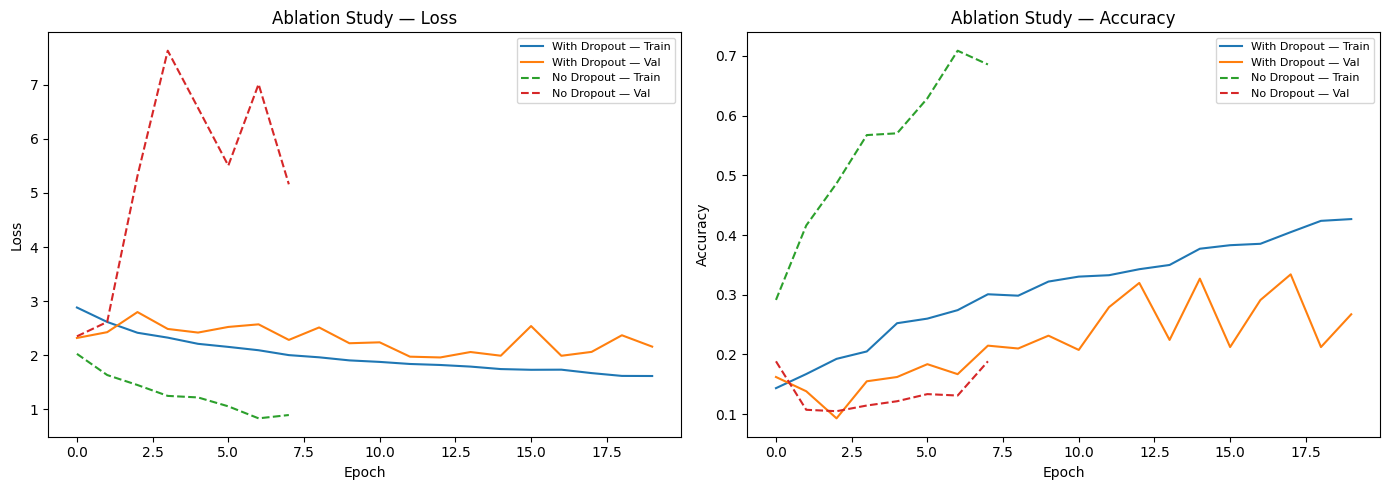

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history_adam.history['loss'],     label='With Dropout — Train')
axes[0].plot(deeper_history_adam.history['val_loss'], label='With Dropout — Val')
axes[0].plot(ablation_history.history['loss'],        label='No Dropout — Train', linestyle='--')
axes[0].plot(ablation_history.history['val_loss'],    label='No Dropout — Val',   linestyle='--')
axes[0].set_title('Ablation Study — Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

axes[1].plot(deeper_history_adam.history['accuracy'],     label='With Dropout — Train')
axes[1].plot(deeper_history_adam.history['val_accuracy'], label='With Dropout — Val')
axes[1].plot(ablation_history.history['accuracy'],        label='No Dropout — Train', linestyle='--')
axes[1].plot(ablation_history.history['val_accuracy'],    label='No Dropout — Val',   linestyle='--')
axes[1].set_title('Ablation Study — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 6.3 Overall Model Comparison Summary (Part A)

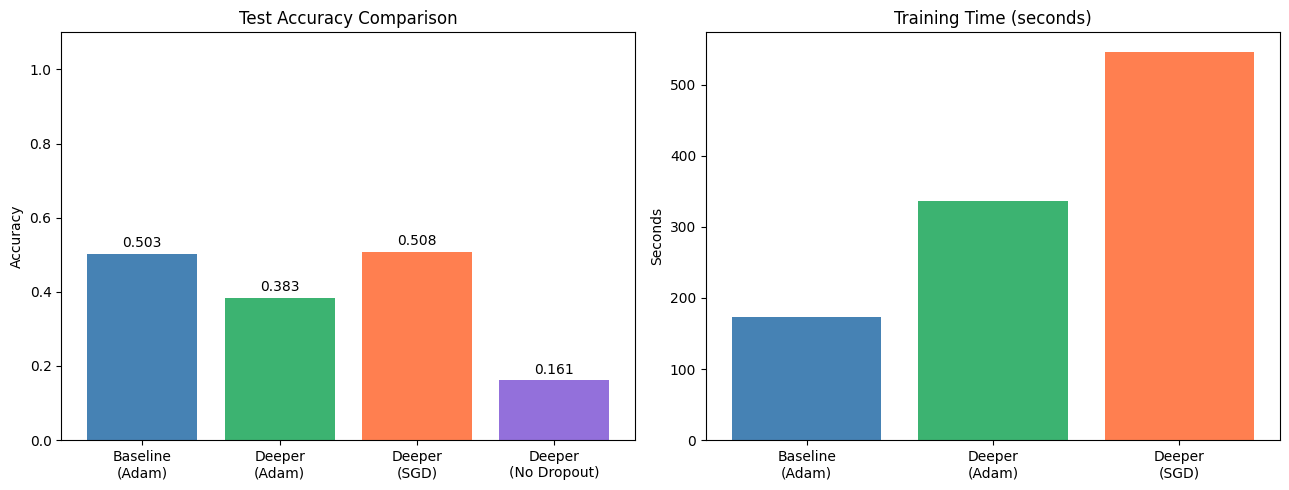

Baseline     accuracy: 0.5026  |  train time: 172.8s
Deeper(Adam) accuracy: 0.3828  |  train time: 336.1s
Deeper(SGD)  accuracy: 0.5078  |  train time: 546.6s
Ablation     accuracy: 0.1615


In [23]:
model_names  = ['Baseline\n(Adam)', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'Deeper\n(No Dropout)']
accuracies   = [baseline_acc, deeper_acc_adam, deeper_acc_sgd, ablation_acc]
train_times  = [baseline_train_time, deeper_train_time_adam, deeper_train_time_sgd, None]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(model_names, accuracies, color=['steelblue','mediumseagreen','coral','mediumpurple'])
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

valid_times  = [t for t in train_times if t is not None]
valid_labels = [n for n, t in zip(model_names, train_times) if t is not None]
axes[1].bar(valid_labels, valid_times, color=['steelblue','mediumseagreen','coral'])
axes[1].set_title('Training Time (seconds)')
axes[1].set_ylabel('Seconds')

plt.tight_layout()
plt.show()

print(f"Baseline     accuracy: {baseline_acc:.4f}  |  train time: {baseline_train_time:.1f}s")
print(f"Deeper(Adam) accuracy: {deeper_acc_adam:.4f}  |  train time: {deeper_train_time_adam:.1f}s")
print(f"Deeper(SGD)  accuracy: {deeper_acc_sgd:.4f}  |  train time: {deeper_train_time_sgd:.1f}s")
print(f"Ablation     accuracy: {ablation_acc:.4f}")

12---
# PART B: Fine-Tuning a Pre-Trained Model (Transfer Learning — Keras / TensorFlow)

**Model selected:** MobileNetV2 pretrained on ImageNet  
**Strategy:** Feature extraction (frozen base) → then fine-tuning (unfreeze top layers)  
**Input size:** 128x128 (required by MobileNetV2, already set in Part A)  
**Framework:** Keras / TensorFlow (consistent with Part A)


In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
# Data generators using MobileNetV2's preprocess_input (-1 to 1 scaling)
IMG_SIZE_TL = (128, 128)
BATCH_SIZE  = 32
SEED        = 42

train_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

test_datagen_tl = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen_tl = train_datagen_tl.flow_from_directory(
    train_path,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen_tl = train_datagen_tl.flow_from_directory(
    train_path,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_gen_tl = test_datagen_tl.flow_from_directory(
    test_path,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names_tl = list(train_gen_tl.class_indices.keys())
num_classes_tl = len(class_names_tl)
print("Classes:", class_names_tl)
print(f"Train batches: {len(train_gen_tl)} | Val batches: {len(val_gen_tl)} | Test batches: {len(test_gen_tl)}")


Found 1692 images belonging to 9 classes.
Found 419 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
Classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']
Train batches: 53 | Val batches: 14 | Test batches: 12


In [26]:
# Build model: frozen MobileNetV2 base + custom classifier head
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze all base layers

inputs = keras.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes_tl, activation='softmax')(x)

tl_model = Model(inputs, outputs)
tl_model.summary()

total_params     = tl_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
print(f"\nTotal params: {total_params:,}  |  Trainable: {trainable_params:,}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total params: 2,588,233  |  Trainable: 330,249


In [27]:
# Phase 1: Feature Extraction — train only the classifier head
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_tl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

t0 = time.time()
fe_history = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=10,
    callbacks=[early_stop_tl],
    verbose=1
)
fe_time = time.time() - t0
print(f"\nFeature extraction training time: {fe_time:.1f}s")


Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 797ms/step - accuracy: 0.6495 - loss: 1.1157 - val_accuracy: 0.7327 - val_loss: 0.9096
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 233ms/step - accuracy: 0.8818 - loss: 0.3860 - val_accuracy: 0.7160 - val_loss: 1.0173
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 234ms/step - accuracy: 0.9332 - loss: 0.2186 - val_accuracy: 0.6921 - val_loss: 1.0789
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.9639 - loss: 0.1538 - val_accuracy: 0.7160 - val_loss: 1.0665
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.9722 - loss: 0.0982 - val_accuracy: 0.7351 - val_loss: 1.1422
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 232ms/step - accuracy: 0.9716 - loss: 0.0923 - val_accuracy: 0.7255 - val_loss: 1.0312

Feature extraction training time: 122.3s


In [28]:
# Phase 2: Fine-tuning — unfreeze the top 30 layers of MobileNetV2
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_now = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
print(f"Trainable params after unfreezing top 30 layers: {trainable_now:,}")

# Recompile with a lower learning rate for fine-tuning
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop_ft = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

t0 = time.time()
ft_history = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=10,
    callbacks=[early_stop_ft, reduce_lr],
    verbose=1
)
ft_time = time.time() - t0
print(f"\nFine-tuning training time: {ft_time:.1f}s")


Trainable params after unfreezing top 30 layers: 1,856,649
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 46s 561ms/step - accuracy: 0.8327 - loss: 0.5205 - val_accuracy: 0.7255 - val_loss: 0.9594 - learning_rate: 1.0000e-04
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 249ms/step - accuracy: 0.9462 - loss: 0.1932 - val_accuracy: 0.7279 - val_loss: 1.0593 - learning_rate: 1.0000e-04
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 240ms/step - accuracy: 0.9710 - loss: 0.1126 - val_accuracy: 0.7422 - val_loss: 0.9954 - learning_rate: 1.0000e-04
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9872 - loss: 0.0757
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 239ms/step - accuracy: 0.9864 - loss: 0.0731 - val_accuracy: 0.7232 - val_loss: 1.1345 - learning_rate: 1.0000e-04
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.9911 - loss: 0.0460 - val_accuracy: 0.7399 - val_loss: 1.1193 - learning_rate: 5.0000e-05
Epoch

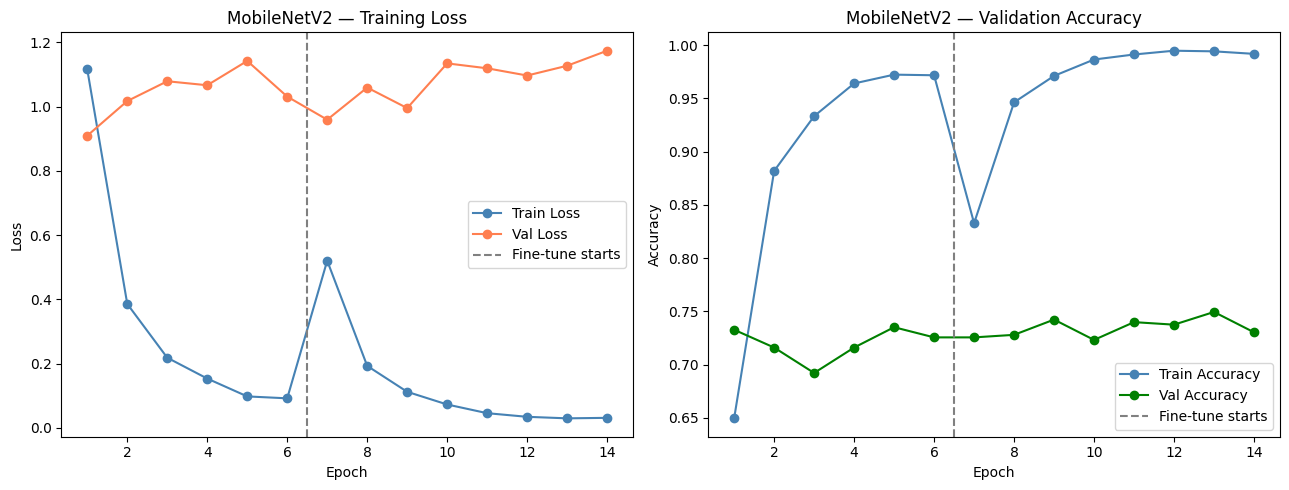

In [29]:
# Plot combined training curves (Feature Extraction + Fine-Tuning)
fe_epochs = len(fe_history.history['loss'])
ft_epochs = len(ft_history.history['loss'])
total_epochs = fe_epochs + ft_epochs
epochs_x = list(range(1, total_epochs + 1))

all_train_loss = fe_history.history['loss']     + ft_history.history['loss']
all_val_loss   = fe_history.history['val_loss'] + ft_history.history['val_loss']
all_train_acc  = fe_history.history['accuracy']     + ft_history.history['accuracy']
all_val_acc    = fe_history.history['val_accuracy'] + ft_history.history['val_accuracy']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_x, all_train_loss, marker='o', label='Train Loss', color='steelblue')
axes[0].plot(epochs_x, all_val_loss,   marker='o', label='Val Loss',   color='coral')
axes[0].axvline(x=fe_epochs + 0.5, color='gray', linestyle='--', label='Fine-tune starts')
axes[0].set_title('MobileNetV2 — Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_x, all_train_acc, marker='o', label='Train Accuracy', color='steelblue')
axes[1].plot(epochs_x, all_val_acc,   marker='o', label='Val Accuracy',   color='green')
axes[1].axvline(x=fe_epochs + 0.5, color='gray', linestyle='--', label='Fine-tune starts')
axes[1].set_title('MobileNetV2 — Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


MobileNetV2 (Transfer Learning) Test Accuracy: 0.8880  |  Loss: 0.3745
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step

Classification Report:
              precision    recall  f1-score   support

      aphids       0.79      0.95      0.87        44
    armyworm       0.85      0.81      0.83        43
      beetle       0.98      0.92      0.95        50
    bollworm       0.89      0.86      0.87        36
 grasshopper       0.90      1.00      0.95        46
       mites       0.95      0.83      0.89        42
    mosquito       0.80      0.98      0.88        50
      sawfly       0.97      0.76      0.85        37
  stem_borer       0.97      0.81      0.88        36

    accuracy                           0.89       384
   macro avg       0.90      0.88      0.89       384
weighted avg       0.90      0.89      0.89       384



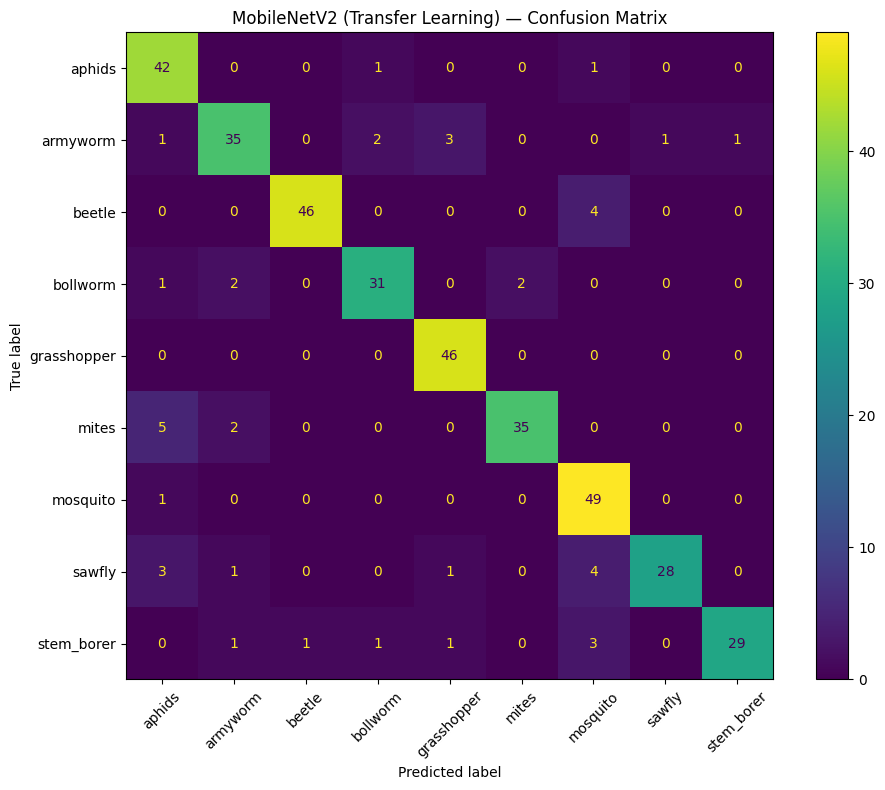

In [30]:
# Evaluate on test set
test_gen_tl.reset()
tl_loss, tl_acc = tl_model.evaluate(test_gen_tl, verbose=0)
print(f"MobileNetV2 (Transfer Learning) Test Accuracy: {tl_acc:.4f}  |  Loss: {tl_loss:.4f}")

test_gen_tl.reset()
tl_preds  = np.argmax(tl_model.predict(test_gen_tl), axis=1)
tl_labels = test_gen_tl.classes

print("\nClassification Report:")
print(classification_report(tl_labels, tl_preds, target_names=class_names_tl))

cm = confusion_matrix(tl_labels, tl_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names_tl)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("MobileNetV2 (Transfer Learning) — Confusion Matrix")
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


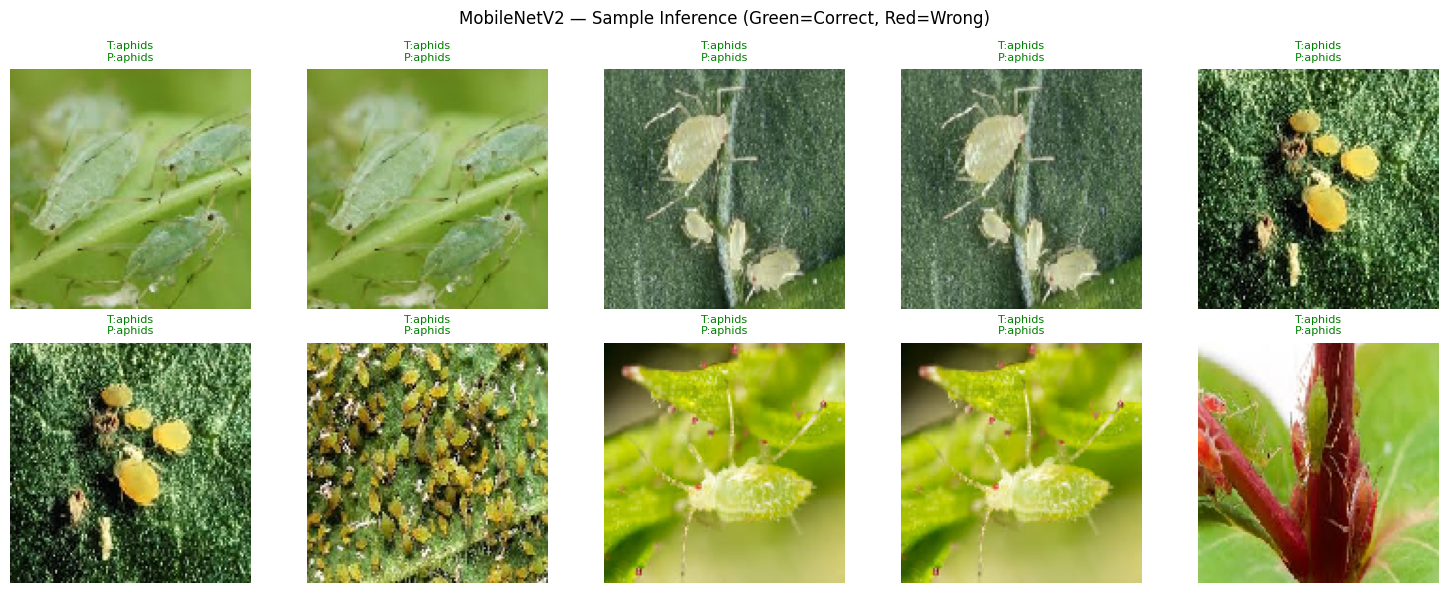

In [31]:
# Sample inference visualization
test_gen_tl.reset()
sample_x_tl, sample_y_tl = next(test_gen_tl)
sample_preds_tl = np.argmax(tl_model.predict(sample_x_tl[:10]), axis=1)
sample_true_tl  = np.argmax(sample_y_tl[:10], axis=1)

# De-normalize from MobileNetV2 preprocess_input range [-1,1] back to [0,1]
sample_display = (sample_x_tl[:10] + 1.0) / 2.0
sample_display = np.clip(sample_display, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_display[i])
    color = 'green' if sample_preds_tl[i] == sample_true_tl[i] else 'red'
    ax.set_title(
        f"T:{class_names_tl[sample_true_tl[i]]}\nP:{class_names_tl[sample_preds_tl[i]]}",
        color=color, fontsize=8
    )
    ax.axis('off')
plt.suptitle("MobileNetV2 — Sample Inference (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()


## 7. Final Comparison: Part A vs Part B

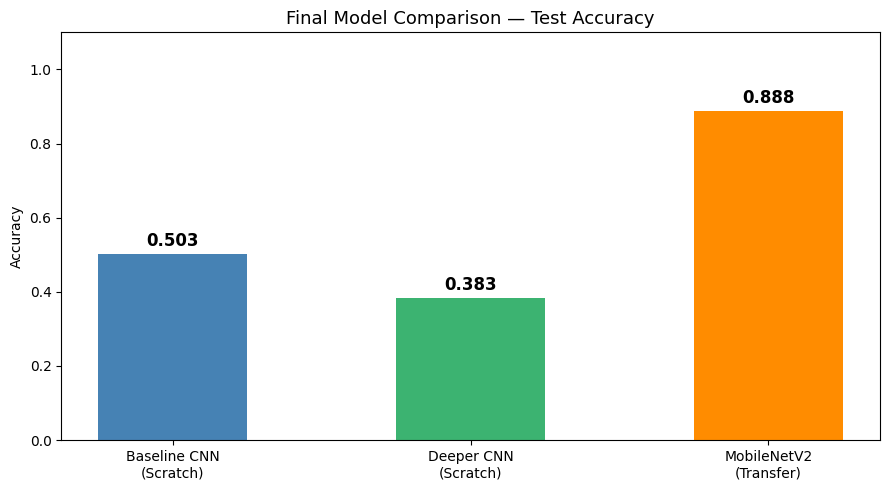


=== Summary ===
Baseline CNN (Scratch)             : 0.5026
Deeper CNN (Scratch)               : 0.3828
MobileNetV2 (Transfer)             : 0.8880


In [32]:
final_models = ['Baseline CNN\n(Scratch)', 'Deeper CNN\n(Scratch)', 'MobileNetV2\n(Transfer)']
final_accs   = [baseline_acc, deeper_acc_adam, tl_acc]
colors       = ['steelblue', 'mediumseagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(final_models, final_accs, color=colors, width=0.5)
ax.set_ylim(0, 1.1)
ax.set_title('Final Model Comparison — Test Accuracy', fontsize=13)
ax.set_ylabel('Accuracy')
for bar, acc in zip(bars, final_accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Summary ===")
for name, acc in zip(final_models, final_accs):
    print(f"{name.replace(chr(10),' '):35s}: {acc:.4f}")
